# ⚡ Gradient Boosting vs. XGBoost vs. AdaBoost

**Dataset:** `unconv_MV_v5.csv`  
**Target:** `Prod` (MCFPD)  
**Features:** `Por` (Porosity %), `Brittle` (Brittleness %)

A systematic comparison of three boosting algorithms through hyperparameter sweeps.  
Each hyperparameter (`n_estimators`, `learning_rate`, `max_depth`) is swept independently  
while the others are held fixed at their GridSearchCV-tuned values.

---

## 📋 Table of Contents
1. [Imports & Setup](#1)
2. [Helper Functions](#2)
3. [Load Data & Train-Test Split](#3)
4. [GridSearchCV — Initial Tuning](#4)
5. [Sweep 1 — n_estimators vs. R² and Training Time](#5)
6. [Sweep 2 — learning_rate vs. R² and Training Time](#6)
7. [Sweep 3 — max_depth vs. R² and Training Time](#7)
8. [Best Hyperparameter Summary](#8)
9. [Key Findings](#9)

---
## 1. Imports & Setup <a id='1'></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FuncFormatter
from matplotlib.colors import ListedColormap
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from IPython.display import display, HTML

RANDOM_STATE = 72
np.random.seed(RANDOM_STATE)

---
## 2. Helper Functions <a id='2'></a>


In [14]:

def comma_format(x, pos):
    return f'{int(x):,}'


def add_grid():
    """Add major and minor gridlines to current axes."""
    plt.gca().grid(True, which='major', linewidth=1.0)
    plt.gca().grid(True, which='minor', linewidth=0.2)
    plt.gca().tick_params(which='major', length=7)
    plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator())


def plot_sweep(x_vals, y_dict, title, xlabel, ylabel):
    """
    Line plot comparing multiple models over a hyperparameter sweep.

    Parameters
    ----------
    x_vals : array-like — hyperparameter values on x-axis
    y_dict : dict       — {model_name: [scores]} mapping
    title  : str        — plot title
    xlabel : str        — x-axis label
    ylabel : str        — y-axis label
    """
    styles = [
        ('Gradient Boosting', 'o', '-'),
        ('XGBoost',           'x', '--'),
        ('AdaBoost',          's', '-.'),
    ]
    plt.figure(figsize=(12, 6))
    for (name, marker, ls) in styles:
        if name in y_dict:
            plt.plot(x_vals, y_dict[name], label=name, marker=marker, linestyle=ls)
    plt.title(title, fontweight='bold'); plt.xlabel(xlabel); plt.ylabel(ylabel)
    plt.legend(); add_grid(); plt.tight_layout(); plt.show()


def display_sidebyside(*args):
    html_str = ''.join(df.head().to_html() for df in args)
    display(HTML(f'<div style="display:flex;gap:20px">{html_str}</div>'))

---
## 3. Load Data & Train-Test Split <a id='3'></a>

In [15]:
df = pd.read_csv("https://raw.githubusercontent.com/Shontu72/python_data-science-learning__-/main/DATA/unconv_MV_v5.csv")

# Replace any negative values with 0 (data quality step)
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].clip(lower=0)

print(f'Shape: {df.shape}')
df.describe().transpose()[['count', 'mean', 'std', 'min', 'max']]

Shape: (200, 8)


,count,mean,std,min,max
Well,200.0,100.500000,57.879185,1.000000,200.000000
Por,200.0,14.991150,2.971176,6.550000,23.550000
Perm,200.0,4.330750,1.731014,1.130000,9.870000
AI,200.0,2.968850,0.566885,1.280000,4.630000
Brittle,200.0,48.161950,14.129455,10.940000,84.330000
TOC,200.0,0.991950,0.478264,0.000000,2.180000
VR,200.0,1.964300,0.300827,0.930000,2.870000
Prod,200.0,4311.219852,992.038414,2107.139414,6662.622385


In [16]:
# Two features selected: Porosity and Brittleness
X = df[['Por', 'Brittle']]
y = df['Prod']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
df_train = pd.concat([X_train, y_train], axis=1)
df_test  = pd.concat([X_test,  y_test],  axis=1)
display_sidebyside(df_train, df_test)

Train: 160 | Test: 40


,Por,Brittle,Prod
18,14.73,67.42,4534.585915
62,18.21,51.06,5620.911404
73,16.62,31.41,4087.529805
107,17.17,38.08,4733.965648
198,15.55,58.25,5087.592149
,Por,Brittle,Prod
177,11.80,35.35,2819.977847
43,11.09,29.62,2677.297348
182,9.88,55.19,3141.540928
169,11.71,44.03,2940.975811


---
## 4. GridSearchCV — Initial Tuning <a id='4'></a>

We run GridSearchCV to get a starting point for each model's best hyperparameters. These are then used as fixed values in the subsequent single-parameter sweeps.

In [17]:
def run_grid_search(model, param_grid, cv=5):
    """
    Run GridSearchCV and return the best parameter dictionary.

    Parameters
    ----------
    model      : sklearn estimator
    param_grid : dict  — hyperparameter search space
    cv         : int   — number of cross-validation folds
    """
    search = GridSearchCV(model, param_grid, cv=cv, scoring='r2', n_jobs=-1)
    search.fit(X_train, y_train)
    return search.best_params_


# ── Model instances ───────────────────────────────────────────────────
gb_model  = GradientBoostingRegressor(
    loss='squared_error', criterion='squared_error', random_state=RANDOM_STATE
)
xgb_model = XGBRegressor(random_state=RANDOM_STATE)
ada_model = AdaBoostRegressor(random_state=RANDOM_STATE)

# ── Search spaces ─────────────────────────────────────────────────────
gb_params  = {'n_estimators': [100, 200, 300, 400],
              'learning_rate': [0.01, 0.05, 0.1, 0.3, 0.5],
              'max_depth':     [2, 3, 5, 7, 8, 10]}
xgb_params = {'n_estimators': [100, 200, 300, 400],
              'learning_rate': [0.01, 0.05, 0.1, 0.3, 0.5],
              'max_depth':     [2, 3, 5, 7, 8, 10]}
ada_params = {'n_estimators': [100, 200, 300, 400],
              'learning_rate': [0.01, 0.05, 0.1, 0.3, 0.5]}

In [18]:
print('Running GridSearchCV for all three models...')

gb_best  = run_grid_search(gb_model,  gb_params)
xgb_best = run_grid_search(xgb_model, xgb_params)
ada_best = run_grid_search(ada_model, ada_params)

print(f'Gradient Boosting best params : {gb_best}')
print(f'XGBoost best params           : {xgb_best}')
print(f'AdaBoost best params          : {ada_best}')

Running GridSearchCV for all three models...
Gradient Boosting best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400}
XGBoost best params           : {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 400}
AdaBoost best params          : {'learning_rate': 0.5, 'n_estimators': 400}


---
## 5. Sweep 1 — n_estimators <a id='5'></a>

We vary the number of trees from 50 to 800 while holding `learning_rate` and `max_depth` fixed at their GridSearchCV values.

In [19]:
num_trees = np.arange(50, 801, 10)

# Fixed params from GridSearchCV (all except n_estimators)
fixed_gb  = {'learning_rate': gb_best['learning_rate'],  'max_depth': gb_best['max_depth']}
fixed_xgb = {'learning_rate': xgb_best['learning_rate'], 'max_depth': xgb_best['max_depth']}
fixed_ada = {'learning_rate': ada_best['learning_rate']}

r2_gb  = []; time_gb  = []
r2_xgb = []; time_xgb = []
r2_ada = []; time_ada = []

for n in num_trees:
    n = int(n)

    t0 = time.time()
    m = GradientBoostingRegressor(n_estimators=n, **fixed_gb,
                                  loss='squared_error', criterion='squared_error',
                                  random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    time_gb.append(time.time() - t0)
    r2_gb.append(r2_score(y_test, m.predict(X_test)))

    t0 = time.time()
    m = XGBRegressor(n_estimators=n, **fixed_xgb, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    time_xgb.append(time.time() - t0)
    r2_xgb.append(r2_score(y_test, m.predict(X_test)))

    t0 = time.time()
    m = AdaBoostRegressor(n_estimators=n, **fixed_ada, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    time_ada.append(time.time() - t0)
    r2_ada.append(r2_score(y_test, m.predict(X_test)))

print('Sweep complete.')

Sweep complete.


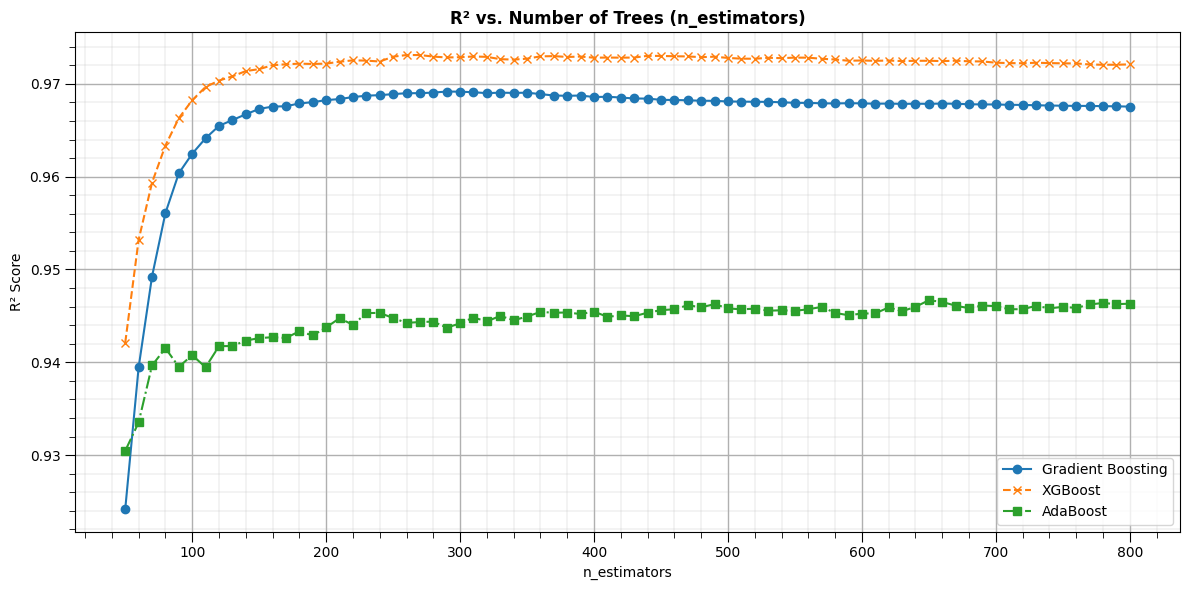

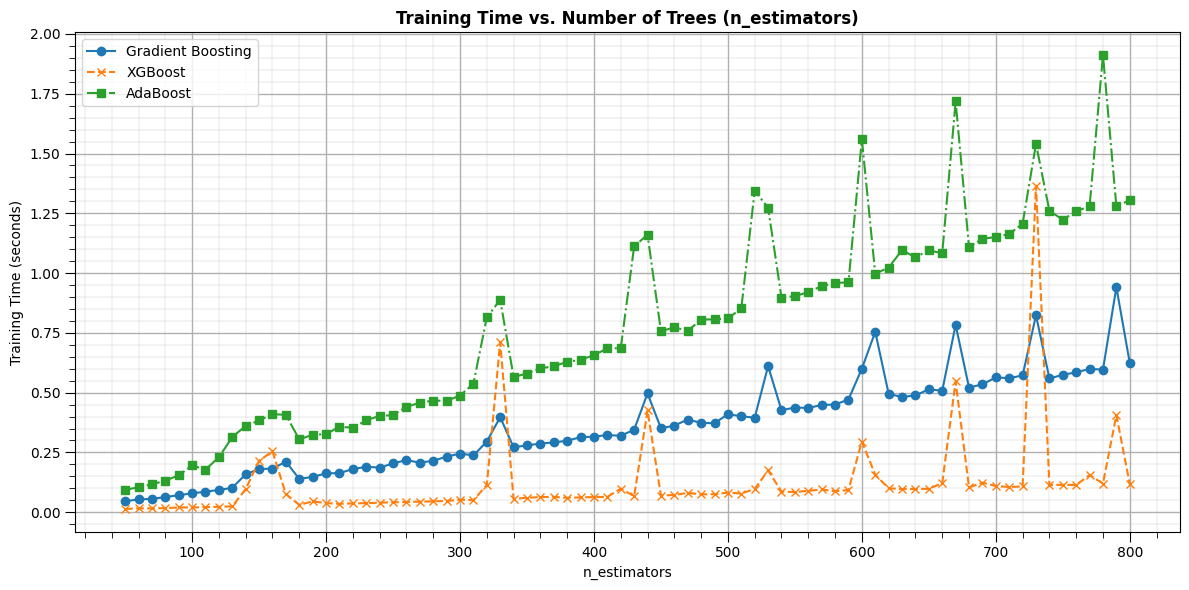

In [20]:
# R² vs. n_estimators
plot_sweep(num_trees,
           {'Gradient Boosting': r2_gb, 'XGBoost': r2_xgb, 'AdaBoost': r2_ada},
           'R² vs. Number of Trees (n_estimators)',
           'n_estimators', 'R² Score')

# Training time vs. n_estimators
plot_sweep(num_trees,
           {'Gradient Boosting': time_gb, 'XGBoost': time_xgb, 'AdaBoost': time_ada},
           'Training Time vs. Number of Trees (n_estimators)',
           'n_estimators', 'Training Time (seconds)')

> **Observation:** XGBoost converges faster and maintains higher R² stability across the n_estimators range. AdaBoost is slow to converge and plateaus at a lower R² ceiling. Gradient Boosting is competitive but more sensitive to the number of trees.

---
## 6. Sweep 2 — learning_rate <a id='6'></a>

We fix `n_estimators=400` and sweep `learning_rate` from 0.01 to 2.0 using the tuned `max_depth` for each model.

In [21]:
FIXED_N = 400
lr_values = np.arange(0.01, 2.01, 0.01)

fixed_md_gb  = gb_best['max_depth']
fixed_md_xgb = xgb_best['max_depth']

r2_gb_lr  = []; time_gb_lr  = []
r2_xgb_lr = []; time_xgb_lr = []
r2_ada_lr = []; time_ada_lr = []

for lr in lr_values:
    t0 = time.time()
    m = GradientBoostingRegressor(n_estimators=FIXED_N, learning_rate=lr,
                                  max_depth=fixed_md_gb,
                                  loss='squared_error', criterion='squared_error',
                                  random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    time_gb_lr.append(time.time() - t0)
    r2_gb_lr.append(r2_score(y_test, m.predict(X_test)))

    t0 = time.time()
    m = XGBRegressor(n_estimators=FIXED_N, learning_rate=lr,
                     max_depth=fixed_md_xgb, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    time_xgb_lr.append(time.time() - t0)
    r2_xgb_lr.append(r2_score(y_test, m.predict(X_test)))

    t0 = time.time()
    m = AdaBoostRegressor(n_estimators=FIXED_N, learning_rate=lr, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    time_ada_lr.append(time.time() - t0)
    r2_ada_lr.append(r2_score(y_test, m.predict(X_test)))

print('Sweep complete.')

Sweep complete.


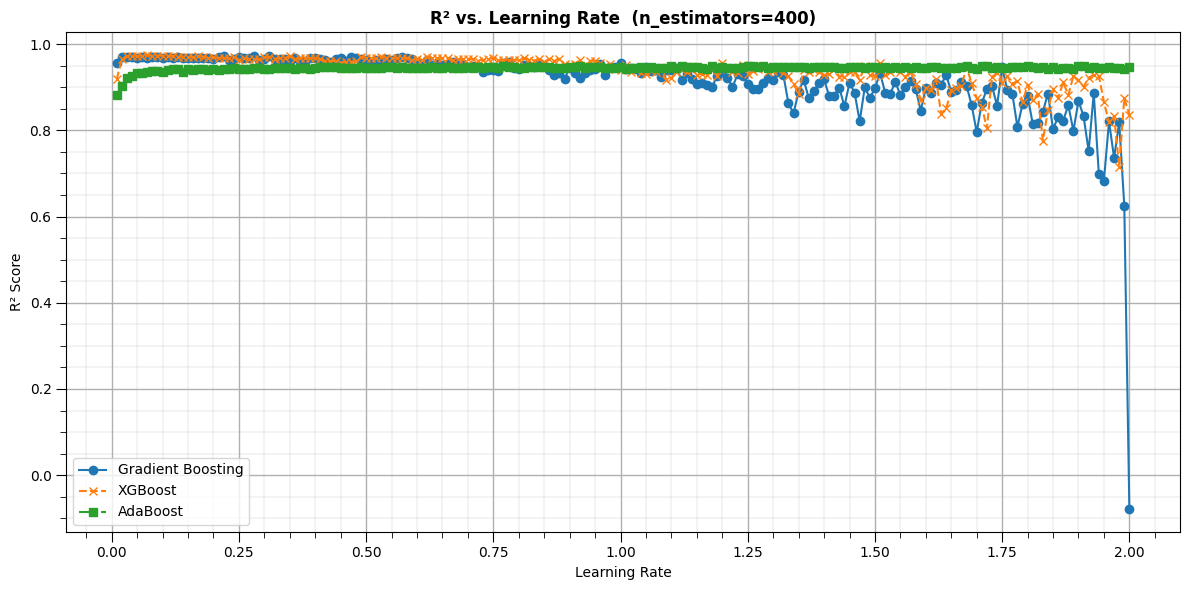

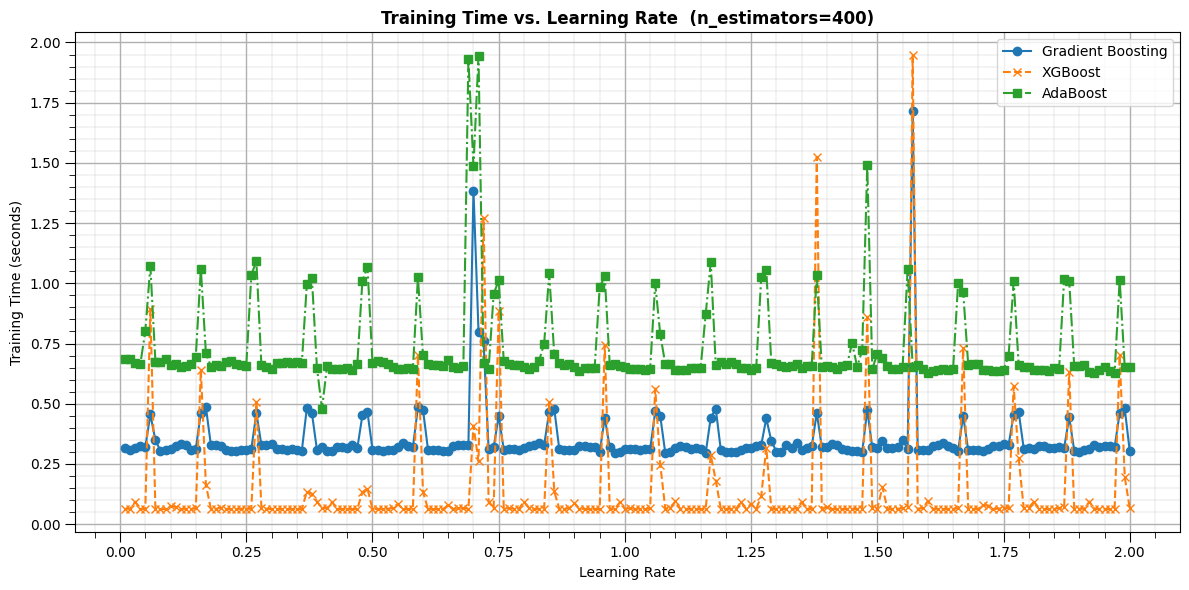

In [22]:
plot_sweep(lr_values,
           {'Gradient Boosting': r2_gb_lr, 'XGBoost': r2_xgb_lr, 'AdaBoost': r2_ada_lr},
           'R² vs. Learning Rate  (n_estimators=400)',
           'Learning Rate', 'R² Score')

plot_sweep(lr_values,
           {'Gradient Boosting': time_gb_lr, 'XGBoost': time_xgb_lr, 'AdaBoost': time_ada_lr},
           'Training Time vs. Learning Rate  (n_estimators=400)',
           'Learning Rate', 'Training Time (seconds)')

> **Observation:**
> - **Gradient Boosting** is highly sensitive to `learning_rate` — performs best in the 0.05–0.3 range, collapses with erratic behaviour beyond 0.75.
> - **XGBoost** is stable up to lr≈1.0 due to built-in L1/L2 regularisation; sweet spot remains 0.05–0.15.
> - **AdaBoost** is practically flat across the entire range — `learning_rate` scales weak learner weights rather than gradient step size, so it has limited effect on this dataset.

---
## 7. Sweep 3 — max_depth <a id='7'></a>

We sweep tree depth from 1 to 96 using the tuned `n_estimators` and `learning_rate` for each model.

In [23]:
depth_values = np.arange(1, 100, 5)

FIXED_N_GB   = gb_best['n_estimators']
FIXED_LR_GB  = gb_best['learning_rate']
FIXED_N_XGB  = xgb_best['n_estimators']
FIXED_LR_XGB = xgb_best['learning_rate']

r2_gb_md  = []; time_gb_md  = []
r2_xgb_md = []; time_xgb_md = []

for md in depth_values:
    md = int(md)

    t0 = time.time()
    m = GradientBoostingRegressor(n_estimators=FIXED_N_GB, learning_rate=FIXED_LR_GB,
                                  max_depth=md, loss='squared_error', criterion='squared_error',
                                  random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    time_gb_md.append(time.time() - t0)
    r2_gb_md.append(r2_score(y_test, m.predict(X_test)))

    t0 = time.time()
    m = XGBRegressor(n_estimators=FIXED_N_XGB, learning_rate=FIXED_LR_XGB,
                     max_depth=md, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    time_xgb_md.append(time.time() - t0)
    r2_xgb_md.append(r2_score(y_test, m.predict(X_test)))

print('Sweep complete.')

Sweep complete.


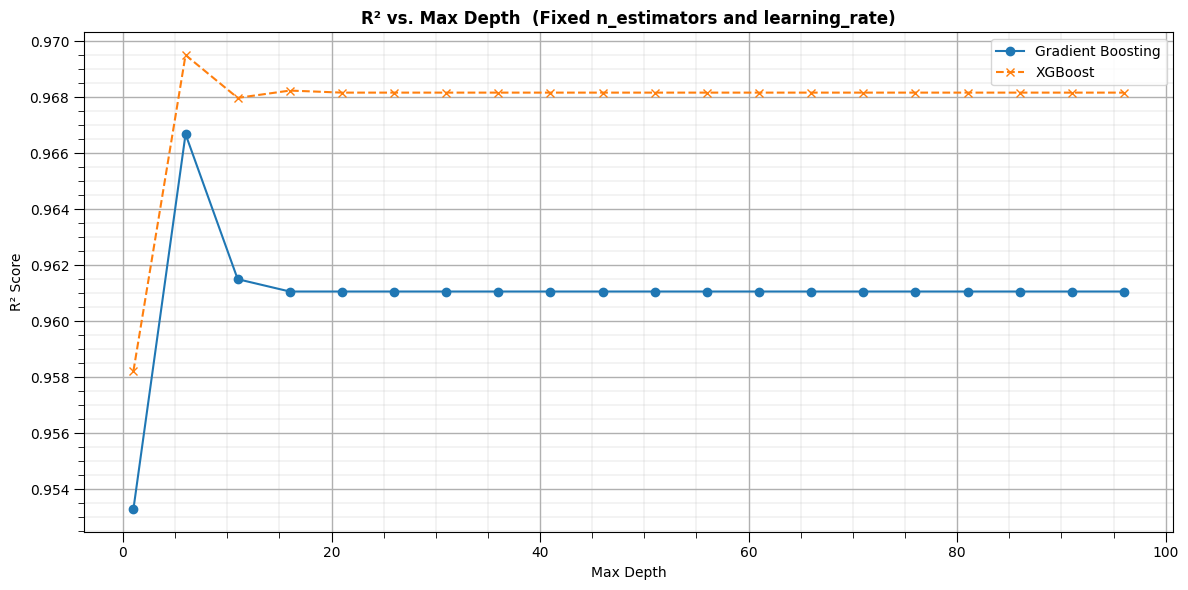

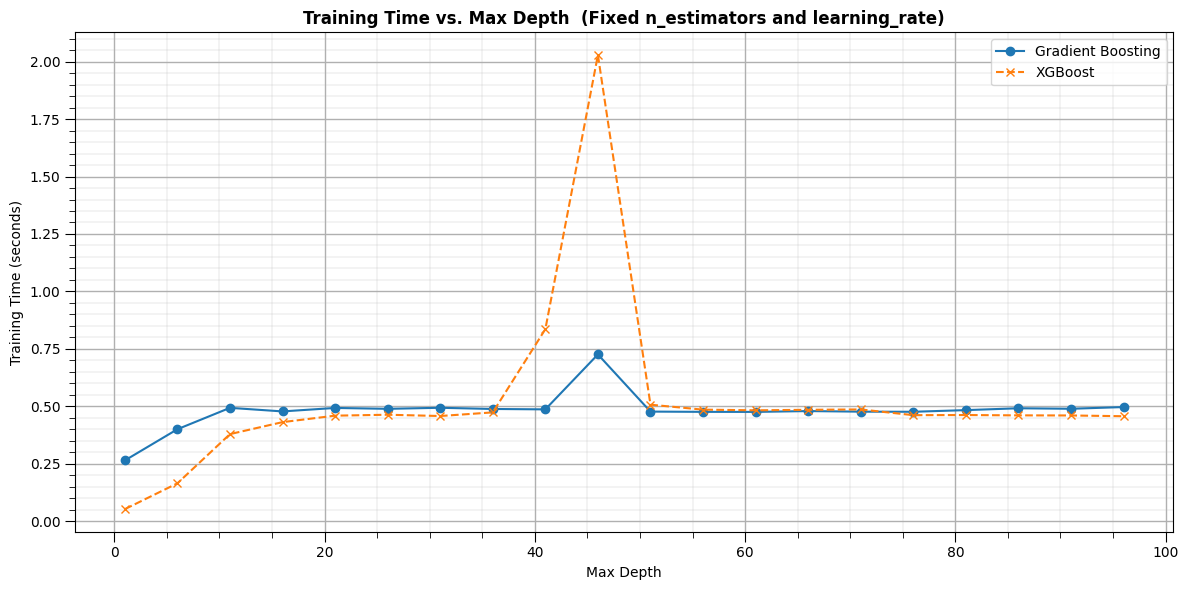

In [24]:
plot_sweep(depth_values,
           {'Gradient Boosting': r2_gb_md, 'XGBoost': r2_xgb_md},
           'R² vs. Max Depth  (Fixed n_estimators and learning_rate)',
           'Max Depth', 'R² Score')

plot_sweep(depth_values,
           {'Gradient Boosting': time_gb_md, 'XGBoost': time_xgb_md},
           'Training Time vs. Max Depth  (Fixed n_estimators and learning_rate)',
           'Max Depth', 'Training Time (seconds)')

> **Observation:**
> - **Gradient Boosting** peaks sharply around depth=6, then plateaus — deeper trees add no value.
> - **XGBoost** peaks at depth=4 and remains stable for any depth beyond that — regularisation prevents overfitting even with very deep trees.
> - Both confirm that **shallow trees (depth 3–7) are optimal** for this 2-feature dataset. Deeper trees only increase compute cost.

---
## 8. Best Hyperparameter Summary <a id='8'></a>

In [25]:
print('─' * 60)
print('Best n_estimators (from sweep 1):')
print(f'  Gradient Boosting : {num_trees[np.argmax(r2_gb)]}   (R²={max(r2_gb):.4f})')
print(f'  XGBoost           : {num_trees[np.argmax(r2_xgb)]}   (R²={max(r2_xgb):.4f})')
print(f'  AdaBoost          : {num_trees[np.argmax(r2_ada)]}   (R²={max(r2_ada):.4f})')

print()
print('Best learning_rate (from sweep 2):')
print(f'  Gradient Boosting : {lr_values[np.argmax(r2_gb_lr)]:.2f}   (R²={max(r2_gb_lr):.4f})')
print(f'  XGBoost           : {lr_values[np.argmax(r2_xgb_lr)]:.2f}  (R²={max(r2_xgb_lr):.4f})')
print(f'  AdaBoost          : {lr_values[np.argmax(r2_ada_lr)]:.2f}  (R²={max(r2_ada_lr):.4f})')

print()
print('Best max_depth (from sweep 3):')
print(f'  Gradient Boosting : {depth_values[np.argmax(r2_gb_md)]}    (R²={max(r2_gb_md):.4f})')
print(f'  XGBoost           : {depth_values[np.argmax(r2_xgb_md)]}    (R²={max(r2_xgb_md):.4f})')
print('─' * 60)
print()
print('Note: peak R² from a sweep does not always equal the globally')
print('optimal hyperparameter — use these values as guidance for')
print('a final combined GridSearchCV or Optuna run.')

────────────────────────────────────────────────────────────
Best n_estimators (from sweep 1):
  Gradient Boosting : 290   (R²=0.9692)
  XGBoost           : 270   (R²=0.9731)
  AdaBoost          : 650   (R²=0.9467)

Best learning_rate (from sweep 2):
  Gradient Boosting : 0.28   (R²=0.9732)
  XGBoost           : 0.07  (R²=0.9745)
  AdaBoost          : 1.91  (R²=0.9497)

Best max_depth (from sweep 3):
  Gradient Boosting : 6    (R²=0.9667)
  XGBoost           : 6    (R²=0.9695)
────────────────────────────────────────────────────────────

Note: peak R² from a sweep does not always equal the globally
optimal hyperparameter — use these values as guidance for
a final combined GridSearchCV or Optuna run.


---    
## Running Models with Best Combined Hyperparameters

Based on the individual sweeps, let's now run each model with its identified optimal combination of hyperparameters and evaluate their performance.

In [29]:
# Gradient Boosting Regressor
gb_n_estimators  = num_trees[np.argmax(r2_gb)]
gb_learning_rate = lr_values[np.argmax(r2_gb_lr)]
gb_max_depth     = depth_values[np.argmax(r2_gb_md)]

gb_final_model = GradientBoostingRegressor(
    n_estimators=gb_n_estimators,
    learning_rate=gb_learning_rate,
    max_depth=gb_max_depth,
    loss='squared_error',
    criterion='squared_error',
    random_state=RANDOM_STATE
)
gb_final_model.fit(X_train, y_train)
gb_pred = gb_final_model.predict(X_test)
gb_r2 = r2_score(y_test, gb_pred)

print(f"Gradient Boosting (Optimal Combined Hyperparameters):")
print(f"  n_estimators: {gb_n_estimators}, learning_rate: {gb_learning_rate:.2f}, max_depth: {gb_max_depth}")
print(f"  R² Score on Test Set: {gb_r2:.4f}")

Gradient Boosting (Optimal Combined Hyperparameters):
  n_estimators: 290, learning_rate: 0.28, max_depth: 6
  R² Score on Test Set: 0.9641


In [30]:
# XGBoost Regressor
xgb_n_estimators  = num_trees[np.argmax(r2_xgb)]
xgb_learning_rate = lr_values[np.argmax(r2_xgb_lr)]
xgb_max_depth     = depth_values[np.argmax(r2_xgb_md)]

xgb_final_model = XGBRegressor(
    n_estimators=xgb_n_estimators,
    learning_rate=xgb_learning_rate,
    max_depth=xgb_max_depth,
    random_state=RANDOM_STATE
)
xgb_final_model.fit(X_train, y_train)
xgb_pred = xgb_final_model.predict(X_test)
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost (Optimal Combined Hyperparameters):")
print(f"  n_estimators: {xgb_n_estimators}, learning_rate: {xgb_learning_rate:.2f}, max_depth: {xgb_max_depth}")
print(f"  R² Score on Test Set: {xgb_r2:.4f}")

XGBoost (Optimal Combined Hyperparameters):
  n_estimators: 270, learning_rate: 0.07, max_depth: 6
  R² Score on Test Set: 0.9692


In [31]:
# AdaBoost Regressor
ada_n_estimators  = num_trees[np.argmax(r2_ada)]
ada_learning_rate = lr_values[np.argmax(r2_ada_lr)]

ada_final_model = AdaBoostRegressor(
    n_estimators=ada_n_estimators,
    learning_rate=ada_learning_rate,
    random_state=RANDOM_STATE
)
ada_final_model.fit(X_train, y_train)
ada_pred = ada_final_model.predict(X_test)
ada_r2 = r2_score(y_test, ada_pred)

print(f"AdaBoost (Optimal Combined Hyperparameters):")
print(f"  n_estimators: {ada_n_estimators}, learning_rate: {ada_learning_rate:.2f}")
print(f"  R² Score on Test Set: {ada_r2:.4f}")

AdaBoost (Optimal Combined Hyperparameters):
  n_estimators: 650, learning_rate: 1.91
  R² Score on Test Set: 0.9480


---
## 9. Key Findings <a id='9'></a>

| # | Finding | Detail |
|---|---|---|
| 1 | **XGBoost wins overall** | Highest R², most stable across all three sweeps, fastest training due to parallelisation |
| 2 | **Gradient Boosting is fragile** | Highly sensitive to `learning_rate` — collapses beyond 0.75 without built-in regularisation |
| 3 | **AdaBoost is structurally weak here** | Depth-1 stumps cannot capture the interaction between Por and Brittle in a single split |
| 4 | **Shallow trees are sufficient** | 2-feature dataset has limited complexity — depth beyond 7 adds zero R² gain for both GB and XGBoost |
| 5 | **Regularisation is the key differentiator** | Same boosting logic underlies GB and XGBoost; XGBoost's λ and α terms provide the stability advantage |
| 6 | **n_estimators plateau quickly** | R² stabilises before n=400 for all three models — more trees are not always better |
| 7 | **Importance of Joint Optimization** | These results emphasize that optimizing hyperparameters one at a time (marginal optimization) does not necessarily lead to the best overall model performance. A more comprehensive joint optimization approach (e.g., using `GridSearchCV` on a full grid or more advanced techniques like `Optuna` or `Hyperopt`) would be crucial for finding the true optimal combination of hyperparameters. |
---